# Build YAML Configurations Files for KL-tools Run With Tully-Fisher Prior from SED Fitting

This notebook will populates the YAML configuration files for each galaxy, including a Tully-Fisher prior on the rotation velocity for each galaxy based on their best-fitting stellar mass and a presummed Tully-Fisher relation. 

### Tully-Fisher Relation

While the TFR can be self-calibrated from the measured galaxy sample assuming zero shear when fitting the grism image, here we adopt existing TFR from literature [Miller et al. (2011)](https://arxiv.org/abs/1102.3911),

$$log(M_*) = [a+b\,log(V_{2.2})] - log(M_0),$$

where $V_{2.2}$ is the rotation velocity at the $r_{2.2}\equiv 2.2\times r_s$, 2.2 times of the disk scale length $r_s$. 

The best fitting coefficients are shown in the table 3 in Miller et al. (2011), grouped by redshift bins and stellar mass being used (i.e. total stellar mass or enclosed stellar mass within $r_{2.2}$). The one with enclosed stellar mass is more accurate,

$$ a=1.718,\, b=3.869,\, \sigma_{\mathrm{int},V}=0.058.$$

for $M_*(r_{2.2})$ v.s. $V_{2.2}$, and for $0.2\leq z \leq 1.3$ all combined. However, when $r_{2.2}$ is not available, the fit with total stellar mass has larger scatter,

$$ a=1.926,\, b=3.783,\, \sigma_{\mathrm{int},V}=0.070.$$

Note that the linear regression is actually done with **the velocity as the dependent variable** in Miller et al. (2011), which is what we want. Therefore, the actually fit is 

$$ log(V_{2.2}) = ((log(M_*)+log(M_0)) - a)/b,$$

and we propagates the stellar mass error to rotation velocity error

$$\sigma(V_{2.2}) = V_{2.2}\times \mathrm{ln}(10) + \sqrt{(\frac{\sigma(\mathrm{lg}(M_\star))}{b})^2 + \sigma_{\mathrm{int}, V}^2}$$

> NOTE: Technically, the proper way to do the fit is: 1) Do bulge-disk decomposition as Miller+11, get the disk scale radius $r_s$ from the fit. 2) Fit multiband SED with a PSF-matched force-aperture photometry. 3) Correct for the aperture in the rest-frame r-band to scale the stellar mass from forced-aperture to $r_{2.2}$ with the curve-of-growth information of each galaxy. 4) Fit a TFR for the galaxy sample by measuring the rotation kinematics and $M_\star$ from grism + image data assuming zero shear. 5) Use the sample TFR to build $V_{2.2}$ prior for each galaxy, based on the aperture-corrected enclosed stellar mass $M_{\star,2.2}$. However, for a fast iteration on KL ggl measurement, we leave this rigorous measurement in future when we are finalizing our results. 

### Catalog Compilation

BTW, we will also collect the best-fitting results from SED fitting and bulge-disk decomposition of each galaxy in this notebook, and produce a v3 source catalog. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, join
import astropy.io.fits as fits
import astropy.units as u
import astropy.constants as const
import prospect.io.read_results as reader
import os
from getdist import plots, MCSamples
import pickle
from astropy.coordinates import SkyCoord
import yaml
import copy

def V22_from_Mstar(Mstar, a, b):
    """
    Calculate V22 from stellar mass using a power-law relation.

    Parameters:
    Mstar : float or array-like
        Stellar mass (in solar masses).
        
    a : float
        Normalization constant.
    b : float
        Power-law index.

    Returns:
    V22 : float or array-like
        Circular velocity at 2.2 disk scale lengths (in km/s).
    """

    Mstar = np.asarray(Mstar)
    V22 = 10**( (np.log10(Mstar)-a) / b)
    return V22

### r22 enclosed TFR, for 0.2<z<1.3, Miller+11
# TFR_a, TFR_b, TFR_sigmaV = 1.718, 3.869, 0.058
### total stellar mass TFR, for 0.2<z<1.3, Miller+11
TFR_a, TFR_b, TFR_sigmaV = 1.926, 3.783, 0.07

/groups/timeifler/jiachuanxu/python_envs/envs/kltools/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
GDN_root = "/xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn"
GDS_root = "/xdisk/timeifler/jiachuanxu/jwst/fresco_gds"
sourcecat_root = "/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/"
YAML_root = "/home/u17/jiachuanxu/kl-tools/yaml"
RUN_dir = "/home/u17/jiachuanxu/kl-tools/scripts"

### Where to find the SED fitting results
GDN_SED_dir = os.path.join(GDN_root, "SED")
GDS_SED_dir = os.path.join(GDS_root, "SED")
SED_bestfit_fmt = "ID%d_DelayedTau_result.h5"

### Save the SED fitting results into table below
GDN_SED_res = []
GDS_SED_res = []
SED_cols = ["ID", "lgMs", "lgMs_err", "V22", "V22_err", "lgV22", "lgV22_err"]
SED_cols_indices = {k:i for i,k in enumerate(SED_cols)}

### The parent source catalog
source_cat_fmt = os.path.join(sourcecat_root, "v2_%s_%s_line_list_low-ground-z_Pa_Br_jades_dr5_blended.fits")
GDN_cat = Table().read(source_cat_fmt % ("gdn", "merged"))
GDS_cat = Table().read(source_cat_fmt % ("gds", "fresco"))

### Where to save the YAML files
GDN_YAML_dir = os.path.join(YAML_root, "congress_fresco_gdn")
GDS_YAML_dir = os.path.join(YAML_root, "fresco_gds")

### Load an example YAML template
### Note: this example YAML template is designed for a disjoint bulge-disk decomposition, i.e., 
# the bulge (2D deV) and disk (3D exp) are not forced to have the same center and orientation. 
# If you want to use a joint bulge-disk decomposition, please modify the example YAML template 
# accordingly. 
# This template also supports multiple grism exposures from multiple emission lines. It also 
# supports independent x-y shift for each grism exposure. Therefore, v0 is fixed to zero. 
example_yaml_fn = os.path.join(YAML_root, "example_jwst_shear_TFR_disjointBD.yaml")
with open(example_yaml_fn, 'r') as f:
    example_yaml = yaml.safe_load(f)

### Also load the bulge-disk decomposition information
GDN_BD_dir = os.path.join(GDN_root, "bulge_disk_2D/ID%d")
GDS_BD_dir = os.path.join(GDS_root, "bulge_disk_2D/ID%d")
BD_bestfit_fmt = "ID_%d_2D_summary.yaml"

GDN_BD_res = []
GDS_BD_res = []

BD_cols_used = ["OBJID", "bt_ratio_fit_mask", "is_runaway_disk", "is_agn_like",
                "bestfit_params/disk_flux", "bestfit_params/disk_x0", "bestfit_params/disk_y0",
                "bestfit_params/disk_hlr", "bestfit_params/disk_b_over_a", "bestfit_params/disk_theta_int", 
                "bestfit_params/bulge_flux", "bestfit_params/bulge_x0", "bestfit_params/bulge_y0",
                "bestfit_params/bulge_hlr", "bestfit_params/bulge_b_over_a", "bestfit_params/bulge_theta_int",
                "bestfit_params/bulge_n",]
BD_cols_rename = ["ID", "BT_ratio", "RUNAWAY_DISK", "AGN_LIKE", 
                   "BD_DISK_FLUX", "BD_DISK_X0", "BD_DISK_Y0", "BD_DISK_HLR", "BD_DISK_B_OVER_A", "BD_DISK_THETA_INT",
                   "BD_BULGE_FLUX", "BD_BULGE_X0", "BD_BULGE_Y0", "BD_BULGE_HLR", "BD_BULGE_B_OVER_A", "BD_BULGE_THETA_INT",
                   "BD_BULGE_N"]
BD_cols_indices = {k:i for i,k in enumerate(BD_cols_rename)}

### Whether to plot the posterior of SED fitting? 
PLOT_SED_POSTERIOR = False

### Where to find the cutouts 
GDS_cutouts_fmt = os.path.join(GDS_root, "data_compile/data_compile_GDS_ID%d_substructdeproj.fits")
GDN_cutouts_fmt = os.path.join(GDN_root, "data_compile/data_compile_GDN_ID%d_substructdeproj.fits")

### Where to save KL fitting results
GDS_KL_dir = os.path.join(GDS_root, "KL_bestfit")
GDN_KL_dir = os.path.join(GDN_root, "KL_bestfit")

### Temper the image or grism likelihood?
IMAGE_TEMP = 1
GRISM_TEMP = 1

In [3]:
test_hdul = fits.open(GDN_cutouts_fmt%(1025078))
test_hdul.info()

Filename: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1025078_substructdeproj.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     114   ()      
  1  PaA_AR        1 ImageHDU        35   (31, 31)   float32   
  2  PaA_ARN       1 ImageHDU        11   (31, 31)   float32   
  3  PaA_ARP       1 ImageHDU        27   (124, 124)   float32   
  4  PAA_ARM       1 ImageHDU        13   (31, 31)   float32   
  5  PaA_BR        1 ImageHDU        35   (31, 31)   float32   
  6  PaA_BRN       1 ImageHDU        11   (31, 31)   float32   
  7  PaA_BRP       1 ImageHDU        27   (124, 124)   float32   
  8  PAA_BRM       1 ImageHDU        13   (31, 31)   float32   
  9  BrG_AR        1 ImageHDU        35   (31, 31)   float32   
 10  BrG_ARN       1 ImageHDU        11   (31, 31)   float32   
 11  BrG_ARP       1 ImageHDU        27   (124, 124)   float32   
 12  BRG_ARM       1 ImageHDU        13   (31, 31)   

In [4]:
test_hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
RA0     =            189.15262 / Reference position RA in direct image          
DEC0    =            62.229668 / Reference position DEC in direct image         
N_COADD =                   32 / Total coadded grism frames                     
N_R     =                   32 / Number of grism-R frames                       
N_C     =                    0 / Number of grism-C frames                       
FILTER  = 'F444W   '           / Photometric filter                             
COMMENTS= 'Below are columns from the input source catalog:'                    
ID      =              1025078                                                  
RA      =            189.152

In [5]:
test_hdul["BrG_BR"].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   31                                                  
NAXIS2  =                   31                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'BrG_BR  '           / extension name                                 
BUNIT   = 'DN/s    '           / Brightness unit (no sensitivity correction)    
PIXSCALE=               0.0629 / Spatial pixel scale (arcsec/pix)               
DISPANG = 0.001990071721259312 / Mean dispersion angle w.r.t. the cutout X axis 
DISPANGW= 6.18177529378628E-05 / Dispersion angle variation among frames (rad)  
FRAME_PA=   0.88458307069935

## GOODS-S

This block process the GOODS-S SED fitting and bulge-disk decomposition info. We fill produce YAML configurations for both KL fit with g1, g2 sampled and TFR included, and also a zero-shear run with g1, g2 fixed to zero, but without TFR included. 

In [ ]:
### shear tag: sample g1 g2 or fix them to zero?
sample_shear = True
if sample_shear:
    shear_tag = "sampleshear"
else:
    shear_tag = "zeroshear"
### overwrite existing YAML?
OVERWRITE_YAML = True
OVERWRITE_CATALOG = False

for i,ID in enumerate(GDS_cat['ID']):
    _SED_BESTFIT_FNAME_ = os.path.join(GDS_SED_dir, SED_bestfit_fmt%ID)
    _SED_POST_FIG_FNAME_ = os.path.join(GDS_SED_dir, f"ID{ID}_SED_corner.png")
    _BD_SUMMARY_FNAME_ = os.path.join(GDS_BD_dir%ID, BD_bestfit_fmt%ID)
    ### ===========================================================================
    ### Load SED fitting results
    ### ===========================================================================
    if os.path.exists(_SED_BESTFIT_FNAME_):
        print(f"Processing {i+1}/{len(GDS_cat)}: ID={ID}")

        results, obs, model = reader.results_from(_SED_BESTFIT_FNAME_)
        # model parameters being sampled
        model_param_names = results["theta_labels"]
        # best-fitting model parameters
        model_param_bestfit=results["bestfit"]["parameter"]
        # parameter range
        total_range = {}
        for p in results["model_params"]:
            if p["isfree"]:
                pp = pickle.loads(p["prior"])
                total_range[p["name"]] = pp.bounds()
        bounds = [total_range[p] for p in model_param_names]
        # read the chain of the MCMC sampling
        chain = results["chain"]
        weights = results["weights"]
        lnpost = results["lnprobability"]
        sample = MCSamples(samples=chain, weights=weights, names=model_param_names, 
                            labels=model_param_names, loglikes=-1*lnpost, ranges=bounds)
        
        if PLOT_SED_POSTERIOR:
            # plot the 2D distribution of the parameters
            g = plots.get_subplot_plotter()
            g.triangle_plot([sample], filled=False, title_limit=1)
            plt.savefig(_SED_POST_FIG_FNAME_)
            plt.close()

        # get the 1D marginal result
        ms = sample.getMargeStats()
        lgMass_ms = ms.parWithName("logMass")

        # get the V22 estimate
        v22 = V22_from_Mstar(10**lgMass_ms.mean, TFR_a, TFR_b)
        lgv22 = np.log10(v22)
        lgv22_err = np.sqrt( (lgMass_ms.err / TFR_b)**2 + TFR_sigmaV**2 )
        v22_err = v22 * np.log(10) * lgv22_err
        # append the result to the table
        GDS_SED_res.append( [ID, lgMass_ms.mean, lgMass_ms.err, 
                                   v22, v22_err, lgv22, lgv22_err] )
    else:
        print(f'object ID={ID} SED failed!\n')
        GDS_SED_res.append( [ID, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan] )

    ### ===========================================================================
    ### Load Bulge-Disk decomposition results
    ### ===========================================================================
    if os.path.exists(_BD_SUMMARY_FNAME_):
        with open(_BD_SUMMARY_FNAME_, 'r') as f:
            bd_summary = yaml.safe_load(f)
        _res_ = []
        for k in BD_cols_used:
            kstring = k.split("/")
            if len(kstring) == 1:
                _res_.append(bd_summary[k])
            elif len(kstring) == 2:
                _res_.append(bd_summary[kstring[0]][kstring[1]])
        GDS_BD_res.append(_res_)
    else:
        print(f'object ID={ID} BD failed!\n')
        GDS_BD_res.append([ID] + [np.nan]*(len(BD_cols_used)-1))
    
    ### ===========================================================================
    ### Build the YAML file for KL fitting
    ### ===========================================================================
    ### -------------------------------------------------------------
    ### I/O info
    ### -------------------------------------------------------------
    yaml_new = copy.deepcopy(example_yaml)
    yaml_new["mcmc"]["data_filename_fmt"] = GDS_cutouts_fmt
    yaml_new["mcmc"]["objid"] = int(ID)
    yaml_new["mcmc"]["output"] = os.path.join(GDS_KL_dir, "ID%d_substructdeproj_%s"%(ID, shear_tag))
    ### -------------------------------------------------------------
    ### Object-dependent info (from cutouts FITS file)
    ### -------------------------------------------------------------
    # emission line names, wavelengths, fluxes, and image flux
    # redshift, number of observations, type of each observation
    eml_names, eml_waves, eml_fluxes, obs_types, obs_temps = [], [], [], [], []
    with fits.open(GDS_cutouts_fmt%ID) as hdul:
        Nobs = hdul[0].header["OBSNUM"]
        z_grism = hdul[0].header["z_grism"]
        for j in range(Nobs):
            tag = hdul[0].header["IMG%d"%(j+1)]
            img_type = hdul[tag].header["OBSTYPE"]
            obs_types.append(img_type)
            obs_temps.append(float(hdul[tag].header["TEMP"]))
            if img_type==2:
                _eml_ = hdul[tag].header["EMISSION"]
                # add new emission line info
                if _eml_ not in eml_names:
                    eml_names.append(_eml_)
                    # get wavelength window
                    wave_grid = np.arange(hdul[tag].header["NAXIS1"]) * hdul[tag].header["D_WAVE"] + hdul[tag].header["WAVE_1"]
                    wave_grid *= 1e3 # um -> nm
                    eml_waves.append([float(wave_grid[0] - (wave_grid[-1]-wave_grid[0])/2.), 
                                      float(wave_grid[-1] + (wave_grid[-1]-wave_grid[0])/2.)])
                    # get flux estimate
                    sens_fn = os.path.join(RUN_dir, hdul[tag].header["BANDPASS"])
                    sens = np.genfromtxt(sens_fn) # nm v.s. DN/s/(phot/s/cm2/nm)
                    assert hdul[tag].header["BUNIT"] == "DN/s"
                    trans = np.interp(wave_grid, sens[:,0], sens[:,1])
                    energy = (const.h * const.c / (wave_grid*u.nm)).to("erg").value
                    _flux_cgs = hdul[tag].data / trans[np.newaxis, :] * energy[np.newaxis, :] * (wave_grid[1]-wave_grid[0])
                    eml_fluxes.append(np.abs(np.sum(_flux_cgs)))
        image_flux = np.sum(hdul["F444WIMG"].data)
    yaml_new["meta"]["sed"]["z"] = float(z_grism)
    ### -------------------------------------------------------------
    ### shared parameters
    ### -------------------------------------------------------------
    # g1, g2
    if sample_shear:
        yaml_new["params"]["g"] = {
            "derived": "lambda g1, g2: np.sqrt(g1*g1+g2*g2)", 
            "latex": "g", 
            "prior": {"clip_sigmas": float(3.0), "dist": "norm", "loc": float(0.0), "scale": float(0.1)}}
    else:
        yaml_new["params"]["g1"] = {"value": float(0.0), "latex": "g_1"}
        yaml_new["params"]["g2"] = {"value": float(0.0), "latex": "g_2"}
        try:
            yaml_new["params"].pop("g")
        except KeyError:
            pass
    # theta_int
    init_PA = GDS_BD_res[-1][BD_cols_indices["BD_DISK_THETA_INT"]]
    yaml_new["params"]["theta_int"]["ref"]["loc"] = float(init_PA) 
    # cosi
    init_cosi = GDS_BD_res[-1][BD_cols_indices["BD_DISK_B_OVER_A"]]
    yaml_new["params"]["cosi"]["ref"]["loc"] = float(init_cosi)
    ### -------------------------------------------------------------
    ### kinematic parameters
    ### -------------------------------------------------------------
    # v0 set to 0 due to degeneracy with grism image offset
    # vcirc
    yaml_new["params"]["vcirc"]["prior"]["min"] = float(30)
    yaml_new["params"]["vcirc"]["prior"]["max"] = float(600)
    yaml_new["params"]["vcirc"]["ref"]["loc"] = float(GDS_SED_res[-1][SED_cols_indices["V22"]])
    # rscale
    yaml_new["params"]["rscale"]["prior"]["min"] = float(0.001)
    yaml_new["params"]["rscale"]["prior"]["max"] = float(2.0)
    # V22: include TFR prior if fitting with shear; sample free otherwise
    if sample_shear:
        yaml_new["params"]["v22"]["prior"]["mu"] = float(GDS_SED_res[-1][SED_cols_indices["V22"]])
        yaml_new["params"]["v22"]["prior"]["dex"] = float(GDS_SED_res[-1][SED_cols_indices["lgV22_err"]])
    else:
        yaml_new["params"]["v22"]["prior"].pop("dist")
        yaml_new["params"]["v22"]["prior"]["min"] = float(30)
        yaml_new["params"]["v22"]["prior"]["max"] = float(600)
    ### -------------------------------------------------------------
    ### Bulge + Disk morphology parameters
    ### -------------------------------------------------------------
    ### >>>>>>>>> Bulge
    yaml_new["params"]["flux"] = {
        "prior": {"min": float(0.1*image_flux), "max": float(10*image_flux)},
        "ref": {"dist": "norm", "loc": float(image_flux), "scale":float(0.1), "proposal": float(1.0e-4)},
        "latex": "F_\mathrm{phot}"
        }
    yaml_new["params"]["F_bulge"] = {
        "prior": {"min": 0.001, "max": 0.999}, 
        "ref": {"dist": "norm", "loc": 0.5, "scale": 0.05, "proposal": 0.05},
        "latex": "F_\mathrm{bulge}"
        }
    yaml_new["params"]["bulge_b_over_a"] = {
        "prior": {"min": 0.01, "max": 1.0},
        "ref": {"dist": "norm", "loc": 0.5, "scale": 0.1, "proposal": 0.1},
        "latex": "{(b/a)}_\mathrm{bulge}"
    }
    # bulge_theta in [-pi/2, pi/2] because there's no velocity
    yaml_new["params"]["bulge_theta"] = {
        "prior": {"min": -np.pi/2., "max": np.pi/2.},
        "ref": {"dist": "norm", "loc": 0.0, "scale": 1.0, "proposal": 1.0},
        "latex": "{\\theta}_\\mathrm{bulge}"
    }
    yaml_new["params"]["hlr_bulge"] = {
        "prior": {"min": 0.0001, "max": 0.30}, 
        "ref": {"dist": "norm", "loc": 0.025, "scale": 0.001, "proposal": 0.001},
        "latex": "R_\mathrm{h, bulge}"
        }
    # RA and DEC offsets are now in arcsec, rather than fractional of hlr
    # NOTE: RA and DEC offsets should be constrained by image tightly, therefore we leave wide priors
    yaml_new["params"]["dx_bulge"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta x_\mathrm{bulge}"
    }
    yaml_new["params"]["dy_bulge"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta y_\mathrm{bulge}"
        }
    ### >>>>>>>>> Disk
    yaml_new["params"]["hlr_disk"] = {
        "prior": {"min": 0.01, "max": 5.0}, 
        "ref": {"dist": "norm", "loc": 0.25, "scale": 0.01, "proposal": 0.0001},
        "latex": "R_\mathrm{h, disk}"
        }
    yaml_new["params"]["qz_disk"] = {
        "prior": {"min": 0.01, "max": 0.3},
        "ref": {"dist": "norm", "loc": 0.1, "scale": 0.01, "proposal": 0.01},
        "latex": "q_z"
        }
    yaml_new["params"]["dx_disk"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta x_\mathrm{disk}"
    }
    yaml_new["params"]["dy_disk"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta y_\mathrm{disk}"
        }
    ### -------------------------------------------------------------
    ### Emission line properties
    ### -------------------------------------------------------------
    for j, eml in enumerate(eml_names):
        ### >>>>>>>>> morphology
        yaml_new["meta"]["intensity"][f"em_{eml}_hlr"] = "param"
        yaml_new["params"][f"em_{eml}_hlr"] = {
            "prior": {"min": float(0.01), "max": float(2.0)},
            "ref": {"dist": "norm", "loc": float(0.2), "scale":float(0.01), "proposal": float(1.0e-4)},
            "latex": "R_\mathrm{h," + eml + "}" 
            }
        ### >>>>>>>>> SED
        yaml_new["meta"]["sed"][f"em_{eml}_flux"] = "param"
        yaml_new["meta"]["sed"][f"em_{eml}_sigma"] = "param"
        yaml_new["params"][f"em_{eml}_flux"] = {
            "prior": {"min": float(5.0e-19), "max": float(1.0e-15)},
            "ref": {"dist": "norm", "loc": float(2.0e-16), "scale":float(1.0e-19), "proposal": float(1.0e-19)},
            "latex": "F_\mathrm{" + eml + "}" 
            }
        yaml_new["params"][f"em_{eml}_sigma"] = {
            "prior": {"min": float( 0.065), "max": float(1.0)},
            "ref": {"dist": "norm", "loc": float(0.65), "scale": float(0.01), "proposal": float(1.0e-4)},
            "latex": "\sigma_\mathrm{" + eml + "}" 
            }
        ### >>>>>>>>> others
        yaml_new["params"][f"em_{eml}_hlr_cap"] = {
            "derived": 'lambda em_%s_hlr, hlr_disk: em_%s_hlr/hlr_disk'%(eml, eml),
            "latex": "\hat{R}_\mathrm{h," + eml + "}",
            "prior": {"min": float(0.01), "max": float(1.5)}
        }
    yaml_new["meta"]["model_dimension"]["lambda_range"] = eml_waves
    ### -------------------------------------------------------------
    ### Observation-dependent nuisance parameters
    ### -------------------------------------------------------------
    # update temperature for each observation
    yaml_new["meta"]["obs_conf_overwrite"] = [{"TEMP": t} for t in obs_temps]
    # x-y offsets for each grism observation
    for j, obs_type in enumerate(obs_types):
        if obs_type == 0: # image, dx/dy degenerate with dx/dy of disk and bulge
            yaml_new["meta"]["intensity"][f"dx_obs{j+1}"] = 0.0
            yaml_new["meta"]["intensity"][f"dy_obs{j+1}"] = 0.0
        else: # grism, dx/dy per exposure
            yaml_new["meta"]["intensity"][f"dx_obs{j+1}"] = "param"
            yaml_new["meta"]["intensity"][f"dy_obs{j+1}"] = "param"
            yaml_new["params"][f"dx_obs{j+1}"] = {
                "prior": {"min": float(-0.3), "max": float(0.3)}, 
                "ref": {"dist": "norm", "loc": float(0.0), "scale":float(0.01), "proposal": float(0.01)},
                "latex": "\Delta x_\mathrm{obs%d}"%(j+1)
                }
            yaml_new["params"][f"dy_obs{j+1}"] = {
                "prior": {"min": float(-0.3), "max": float(0.3)}, 
                "ref": {"dist": "norm", "loc": float(0.0), "scale":float(0.01), "proposal": float(0.01)},
                "latex": "\Delta y_\mathrm{obs%d}"%(j+1)
                }
    ### -------------------------------------------------------------
    ### Save into disk
    ### -------------------------------------------------------------
    new_yaml_fn = os.path.join(GDS_YAML_dir, "ID%d_substructdeproj_%s.yaml"%(ID, shear_tag))
    if (not os.path.exists(new_yaml_fn)) or OVERWRITE_YAML:
        with open(new_yaml_fn, 'w') as f:
            yaml.dump(yaml_new, f)

Processing 1/281: ID=74131
Removed no burn in
Processing 2/281: ID=76682
Removed no burn in
Processing 3/281: ID=85484


Removed no burn in
Processing 4/281: ID=94908
Removed no burn in
Processing 5/281: ID=95680


Removed no burn in
Processing 6/281: ID=99892


Removed no burn in
Processing 7/281: ID=105191
Removed no burn in
Processing 8/281: ID=111621
Removed no burn in
Processing 9/281: ID=113418


Removed no burn in
Processing 10/281: ID=113730
Removed no burn in
Processing 11/281: ID=114914


...

Removed no burn in
Processing 260/281: ID=244663
Removed no burn in
Processing 261/281: ID=244754


Removed no burn in
Processing 262/281: ID=244962


Removed no burn in
Processing 263/281: ID=245146
Removed no burn in
Processing 264/281: ID=245392
Removed no burn in
Processing 265/281: ID=245521
Removed no burn in
Processing 266/281: ID=245731
Removed no burn in
Processing 267/281: ID=245894
Removed no burn in
Processing 268/281: ID=246096
Removed no burn in
Processing 269/281: ID=333721
Removed no burn in
Processing 270/281: ID=379317
Removed no burn in
Processing 271/281: ID=394021
Removed no burn in
Processing 272/281: ID=400532
Removed no burn in
Processing 273/281: ID=404093
Removed no burn in
Processing 274/281: ID=405239
Removed no burn in
Processing 275/281: ID=405626
Removed no burn in
Processing 276/281: ID=408675


Removed no burn in
Processing 277/281: ID=408991
Removed no burn in
Processing 278/281: ID=409939
Removed no burn in
Processing 279/281: ID=411977


Removed no burn in
Processing 280/281: ID=421003
Removed no burn in
Processing 281/281: ID=428203
Removed no burn in


In [17]:
%matplotlib inline
GDN_cat

ID,RA,DEC,A,B,PA,F090W_CIRC1,F115W_CIRC1,F150W_CIRC1,F182M_CIRC1,F200W_CIRC1,F210M_CIRC1,F277W_CIRC1,F335M_CIRC1,F356W_CIRC1,F410M_CIRC1,F444W_CIRC1,F444W_CIRC2,F444W_CIRC4,F444W_ratio_42,F356W_mag,F444W_mag,z_a,z_16,z_84,EAZY_l95,EAZY_u95,EAZY_chisq_min,PI,Wrong_ID,z_spec,z_conf,z_ref,cF090W_CIRC1,cF090W_CIRC1_e,cF115W_CIRC1,cF115W_CIRC1_e,cF356W_CIRC1,cF356W_CIRC1_e,wave_line_exp,name_line_exp,wave,SN_peak,flux_peak,bins,fit_center_um,fit_center_um_e,fit_flux_cgs,fit_flux_cgs_e,fit_fwhm_um,fit_fwhm_um_e,fit_line_SN,pseudo_line_EW,BLEND_FLUX_RATIO,FWHM,A_KRON,B_KRON,F444W_KRON,F444W_KRON_e,F444W_KRON_S,F444W_KRON_S_e,F444W_CIRC2_e,F444W_CIRC2_ei,z_grism,F070W_TOT,F070W_TOT_e,F090W_TOT,F090W_TOT_e,F115W_TOT,F115W_TOT_e,F150W_TOT,F150W_TOT_e,F162M_TOT,F162M_TOT_e,F182M_TOT,F182M_TOT_e,F200W_TOT,F200W_TOT_e,F210M_TOT,F210M_TOT_e,F277W_TOT,F277W_TOT_e,F300M_TOT,F300M_TOT_e,F335M_TOT,F335M_TOT_e,F356W_TOT,F356W_TOT_e,F410M_TOT,F410M_TOT_e,F430M_TOT,F430M_TOT_e,F444W_TOT,F444W_TOT_e,F460M_TOT,F460M_TOT_e,F435W_TOT,F435W_TOT_e,F606W_TOT,F606W_TOT_e,F775W_TOT,F775W_TOT_e,F814W_TOT,F814W_TOT_e,F850LP_TOT,F850LP_TOT_e,F105W_TOT,F105W_TOT_e,F125W_TOT,F125W_TOT_e,F140W_TOT,F140W_TOT_e,F160W_TOT,F160W_TOT_e
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes5,int64,float64,bytes3,bytes16,float64,float64,float64,float64,float64,float64,float64,bytes3,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1000260,189.0652,62.218117,0.13710523353050685,0.11256961665173568,74.402115,317.4,378.8,346.4,338.3,370.6,410.5,250.4,0.0,194.9,158.6,176.2,230.39268493652344,372.3,1.6283,24.28,24.54,0.21,0.181,0.225,0.108,0.237,17.796,JADES,143213,0.1689,Z,Barger_ACS,304.26,7.73,369.04,7.88,163.53,3.64,4.73665,BrA,4.738,7.649,0.004712,4,4.73776,0.00024,-17.50688,0.06337,0.00342,0.00057,6.853,0.0382,0.0,0.29538568710368973,0.479868317356774,0.3939936582810749,449.3346886660315,10.399652318231482,335.8636998615118,5.480254556568077,3.0006134510040283,1.5359783172607422,0.16952851147864711,--,--,1195.94584538363,28.955994441005206,1390.033646801879,20.10766540033185,1430.8431349376085,31.20251123552807,--,--,1392.8602993629656,37.805841652371655,1476.384235276794,31.484467665518046,1328.1469257223325,44.72776053533769,923.1432198790294,25.242547776220494,--,--,--,--,690.6987527569419,15.065432951633953,557.1508347441094,16.947558193774256,--,--,531.1428158816204,14.82792290528311,--,--,622.2447564884825,25.879654141298264,1081.3079547633115,21.17915239960952,1256.7476484239137,27.799861131738442,1283.8303936229215,21.071321741691413,1255.4296564191898,33.777473551298876,1231.482610374296,28.86914929272612,1301.7396682595192,42.45092219670357,1187.044530994404,3604.8995413047332,1334.9221835916214,48.21495000095384
1000898,189.12352,62.223602,0.20712481897155277,0.14895136364996683,23.78913,203.1,231.3,243.0,263.3,286.4,267.0,339.4,336.1,319.7,256.5,254.4,441.4195556640625,954.8,2.3862,22.953,23.322,0.66,0.644,0.717,0.616,0.801,15.944,JADES,240513,0.7612,Z,Barger_UV,187.92,8.67,212.19,10.08,269.86,12.56,3.30331,PaA,3.305,7.074,0.001438,8,3.30439,0.00035,-17.48891,0.0672,0.00455,0.00081,6.463,0.0063,0.0,0.42480587344652954,0.7249368664004348,0.5213297727748839,1518.4822521307149,9.681928304667805,989.5645995562617,5.131383938867234,1.9497522115707397,1.054303765296936,

In [7]:
# Save the v3 catalog including SED and Bulge-Disk decomposition results
GDS_SED_tab = Table(np.array(GDS_SED_res), names=SED_cols)
GDS_BD_tab = Table(np.array(GDS_BD_res), names=BD_cols_rename, 
                   dtype = [int, float, bool, bool, str, ] + [float]*(len(BD_cols_rename)-5))
GDS_cat_v3 = join(GDS_cat, GDS_SED_tab, keys="ID", join_type="left")
GDS_cat_v3 = join(GDS_cat_v3, GDS_BD_tab, keys="ID", join_type="left")
#GDS_cat_v3.write( (source_cat_fmt%("gds", "fresco")).replace("v2", "v3"), overwrite=OVERWRITE_CATALOG)

## GOODS-N

In [ ]:
### shear tag: sample g1 g2 or fix them to zero?
sample_shear = True
if sample_shear:
    shear_tag = "sampleshear"
else:
    shear_tag = "zeroshear"
### overwrite existing YAML?
OVERWRITE_YAML = True
OVERWRITE_CATALOG = False

for i,ID in enumerate(GDN_cat['ID']):
    _SED_BESTFIT_FNAME_ = os.path.join(GDN_SED_dir, SED_bestfit_fmt%ID)
    _SED_POST_FIG_FNAME_ = os.path.join(GDN_SED_dir, f"ID{ID}_SED_corner.png")
    _BD_SUMMARY_FNAME_ = os.path.join(GDN_BD_dir%ID, BD_bestfit_fmt%ID)
    ### ===========================================================================
    ### Load SED fitting results
    ### ===========================================================================
    if os.path.exists(_SED_BESTFIT_FNAME_):
        print(f"Processing {i+1}/{len(GDN_cat)}: ID={ID}")

        results, obs, model = reader.results_from(_SED_BESTFIT_FNAME_)
        # model parameters being sampled
        model_param_names = results["theta_labels"]
        # best-fitting model parameters
        model_param_bestfit=results["bestfit"]["parameter"]
        # parameter range
        total_range = {}
        for p in results["model_params"]:
            if p["isfree"]:
                pp = pickle.loads(p["prior"])
                total_range[p["name"]] = pp.bounds()
        bounds = [total_range[p] for p in model_param_names]
        # read the chain of the MCMC sampling
        chain = results["chain"]
        weights = results["weights"]
        lnpost = results["lnprobability"]
        sample = MCSamples(samples=chain, weights=weights, names=model_param_names, 
                            labels=model_param_names, loglikes=-1*lnpost, ranges=bounds)
        
        if PLOT_SED_POSTERIOR:
            # plot the 2D distribution of the parameters
            g = plots.get_subplot_plotter()
            g.triangle_plot([sample], filled=False, title_limit=1)
            plt.savefig(_SED_POST_FIG_FNAME_)
            plt.close()

        # get the 1D marginal result
        ms = sample.getMargeStats()
        lgMass_ms = ms.parWithName("logMass")

        # get the V22 estimate
        v22 = V22_from_Mstar(10**lgMass_ms.mean, TFR_a, TFR_b)
        lgv22 = np.log10(v22)
        lgv22_err = np.sqrt( (lgMass_ms.err / TFR_b)**2 + TFR_sigmaV**2 )
        v22_err = v22 * np.log(10) * lgv22_err
        # append the result to the table
        GDN_SED_res.append( [ID, lgMass_ms.mean, lgMass_ms.err, 
                                   v22, v22_err, lgv22, lgv22_err] )
    else:
        print(f'object ID={ID} SED failed!\n')
        GDN_SED_res.append( [ID, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan] )

    ### ===========================================================================
    ### Load Bulge-Disk decomposition results
    ### ===========================================================================
    if os.path.exists(_BD_SUMMARY_FNAME_):
        with open(_BD_SUMMARY_FNAME_, 'r') as f:
            bd_summary = yaml.safe_load(f)
        _res_ = []
        for k in BD_cols_used:
            kstring = k.split("/")
            if len(kstring) == 1:
                _res_.append(bd_summary[k])
            elif len(kstring) == 2:
                _res_.append(bd_summary[kstring[0]][kstring[1]])
        GDN_BD_res.append(_res_)
    else:
        print(f'object ID={ID} BD failed!\n')
        GDN_BD_res.append([ID] + [np.nan]*(len(BD_cols_used)-1))
    
    ### ===========================================================================
    ### Build the YAML file for KL fitting
    ### ===========================================================================
    ### -------------------------------------------------------------
    ### I/O info
    ### -------------------------------------------------------------
    yaml_new = copy.deepcopy(example_yaml)
    yaml_new["mcmc"]["data_filename_fmt"] = GDN_cutouts_fmt
    yaml_new["mcmc"]["objid"] = int(ID)
    yaml_new["mcmc"]["output"] = os.path.join(GDN_KL_dir, "ID%d_substructdeproj_%s"%(ID, shear_tag))
    ### -------------------------------------------------------------
    ### Object-dependent info (from cutouts FITS file)
    ### -------------------------------------------------------------
    # emission line names, wavelengths, fluxes, and image flux
    # redshift, number of observations, type of each observation
    eml_names, eml_waves, eml_fluxes, obs_types, obs_temps = [], [], [], [], []
    with fits.open(GDN_cutouts_fmt%ID) as hdul:
        Nobs = hdul[0].header["OBSNUM"]
        z_grism = hdul[0].header["z_grism"]
        for j in range(Nobs):
            tag = hdul[0].header["IMG%d"%(j+1)]
            img_type = hdul[tag].header["OBSTYPE"]
            obs_types.append(img_type)
            obs_temps.append(float(hdul[tag].header["TEMP"]))
            if img_type==2:
                _eml_ = hdul[tag].header["EMISSION"]
                # add new emission line info
                if _eml_ not in eml_names:
                    eml_names.append(_eml_)
                    # get wavelength window
                    wave_grid = np.arange(hdul[tag].header["NAXIS1"]) * hdul[tag].header["D_WAVE"] + hdul[tag].header["WAVE_1"]
                    wave_grid *= 1e3 # um -> nm
                    eml_waves.append([float(wave_grid[0] - (wave_grid[-1]-wave_grid[0])/2.), 
                                      float(wave_grid[-1] + (wave_grid[-1]-wave_grid[0])/2.)])
                    # get flux estimate
                    sens_fn = os.path.join(RUN_dir, hdul[tag].header["BANDPASS"])
                    sens = np.genfromtxt(sens_fn) # nm v.s. DN/s/(phot/s/cm2/nm)
                    assert hdul[tag].header["BUNIT"] == "DN/s"
                    trans = np.interp(wave_grid, sens[:,0], sens[:,1])
                    energy = (const.h * const.c / (wave_grid*u.nm)).to("erg").value
                    _flux_cgs = hdul[tag].data / trans[np.newaxis, :] * energy[np.newaxis, :] * (wave_grid[1]-wave_grid[0])
                    eml_fluxes.append(np.abs(np.sum(_flux_cgs)))
        image_flux = np.sum(hdul["F444WIMG"].data)
    yaml_new["meta"]["sed"]["z"] = float(z_grism)
    ### -------------------------------------------------------------
    ### shared parameters
    ### -------------------------------------------------------------
    # g1, g2
    if sample_shear:
        yaml_new["params"]["g"] = {
            "derived": "lambda g1, g2: np.sqrt(g1*g1+g2*g2)", 
            "latex": "g", 
            "prior": {"clip_sigmas": float(3.0), "dist": "norm", "loc": float(0.0), "scale": float(0.1)}}
    else:
        yaml_new["params"]["g1"] = {"value": float(0.0), "latex": "g_1"}
        yaml_new["params"]["g2"] = {"value": float(0.0), "latex": "g_2"}
        try:
            yaml_new["params"].pop("g")
        except KeyError:
            pass
    # theta_int
    init_PA = GDN_BD_res[-1][BD_cols_indices["BD_DISK_THETA_INT"]]
    yaml_new["params"]["theta_int"]["ref"]["loc"] = float(init_PA) 
    # cosi
    init_cosi = GDN_BD_res[-1][BD_cols_indices["BD_DISK_B_OVER_A"]]
    yaml_new["params"]["cosi"]["ref"]["loc"] = float(init_cosi)
    ### -------------------------------------------------------------
    ### kinematic parameters
    ### -------------------------------------------------------------
    # v0 set to 0 due to degeneracy with grism image offset
    # vcirc
    yaml_new["params"]["vcirc"]["prior"]["min"] = float(30)
    yaml_new["params"]["vcirc"]["prior"]["max"] = float(600)
    yaml_new["params"]["vcirc"]["ref"]["loc"] = float(GDN_SED_res[-1][SED_cols_indices["V22"]])
    # rscale
    yaml_new["params"]["rscale"]["prior"]["min"] = float(0.001)
    yaml_new["params"]["rscale"]["prior"]["max"] = float(2.0)
    # V22: include TFR prior if fitting with shear; sample free otherwise
    if sample_shear:
        yaml_new["params"]["v22"]["prior"]["mu"] = float(GDN_SED_res[-1][SED_cols_indices["V22"]])
        yaml_new["params"]["v22"]["prior"]["dex"] = float(GDN_SED_res[-1][SED_cols_indices["lgV22_err"]])
    else:
        yaml_new["params"]["v22"]["prior"].pop("dist")
        yaml_new["params"]["v22"]["prior"]["min"] = float(30)
        yaml_new["params"]["v22"]["prior"]["max"] = float(600)
    ### -------------------------------------------------------------
    ### Bulge + Disk morphology parameters
    ### -------------------------------------------------------------
    ### >>>>>>>>> Bulge
    yaml_new["params"]["flux"] = {
        "prior": {"min": float(0.1*image_flux), "max": float(10*image_flux)},
        "ref": {"dist": "norm", "loc": float(image_flux), "scale":float(0.1), "proposal": float(1.0e-4)},
        "latex": "F_\mathrm{phot}"
        }
    yaml_new["params"]["F_bulge"] = {
        "prior": {"min": 0.001, "max": 0.999}, 
        "ref": {"dist": "norm", "loc": 0.5, "scale": 0.05, "proposal": 0.05},
        "latex": "F_\mathrm{bulge}"
        }
    yaml_new["params"]["bulge_b_over_a"] = {
        "prior": {"min": 0.01, "max": 1.0},
        "ref": {"dist": "norm", "loc": 0.5, "scale": 0.1, "proposal": 0.1},
        "latex": "{(b/a)}_\mathrm{bulge}"
    }
    # bulge_theta in [-pi/2, pi/2] because there's no velocity
    yaml_new["params"]["bulge_theta"] = {
        "prior": {"min": -np.pi/2., "max": np.pi/2.},
        "ref": {"dist": "norm", "loc": 0.0, "scale": 1.0, "proposal": 1.0},
        "latex": "{\\theta}_\\mathrm{bulge}"
    }
    yaml_new["params"]["hlr_bulge"] = {
        "prior": {"min": 0.0001, "max": 0.30}, 
        "ref": {"dist": "norm", "loc": 0.025, "scale": 0.001, "proposal": 0.001},
        "latex": "R_\mathrm{h, bulge}"
        }
    # RA and DEC offsets are now in arcsec, rather than fractional of hlr
    # NOTE: RA and DEC offsets should be constrained by image tightly, therefore we leave wide priors
    yaml_new["params"]["dx_bulge"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta x_\mathrm{bulge}"
    }
    yaml_new["params"]["dy_bulge"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta y_\mathrm{bulge}"
        }
    ### >>>>>>>>> Disk
    yaml_new["params"]["hlr_disk"] = {
        "prior": {"min": 0.01, "max": 5.0}, 
        "ref": {"dist": "norm", "loc": 0.25, "scale": 0.01, "proposal": 0.0001},
        "latex": "R_\mathrm{h, disk}"
        }
    yaml_new["params"]["qz_disk"] = {
        "prior": {"min": 0.01, "max": 0.3},
        "ref": {"dist": "norm", "loc": 0.1, "scale": 0.01, "proposal": 0.01},
        "latex": "q_z"
        }
    yaml_new["params"]["dx_disk"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta x_\mathrm{disk}"
    }
    yaml_new["params"]["dy_disk"] = {
        "prior": {"min": -0.3, "max": 0.3}, 
        "ref": {"dist": "norm", "loc": 0.0, "scale": 0.01, "proposal": 0.01},
        "latex": "\Delta y_\mathrm{disk}"
        }
    ### -------------------------------------------------------------
    ### Emission line properties
    ### -------------------------------------------------------------
    for j, eml in enumerate(eml_names):
        ### >>>>>>>>> morphology
        yaml_new["meta"]["intensity"][f"em_{eml}_hlr"] = "param"
        yaml_new["params"][f"em_{eml}_hlr"] = {
            "prior": {"min": float(0.01), "max": float(2.0)},
            "ref": {"dist": "norm", "loc": float(0.2), "scale":float(0.01), "proposal": float(1.0e-4)},
            "latex": "R_\mathrm{h," + eml + "}" 
            }
        ### >>>>>>>>> SED
        yaml_new["meta"]["sed"][f"em_{eml}_flux"] = "param"
        yaml_new["meta"]["sed"][f"em_{eml}_sigma"] = "param"
        yaml_new["params"][f"em_{eml}_flux"] = {
            "prior": {"min": float(0.0), "max": float(1.0)},
            "ref": {"dist": "norm", "loc": float(2.0e-16), "scale":float(1.0e-19), "proposal": float(1.0e-19)},
            "latex": "F_\mathrm{" + eml + "}" 
            }
        yaml_new["params"][f"em_{eml}_sigma"] = {
            "prior": {"min": float( 0.065), "max": float(1.0)},
            "ref": {"dist": "norm", "loc": float(0.65), "scale": float(0.01), "proposal": float(1.0e-4)},
            "latex": "\sigma_\mathrm{" + eml + "}" 
            }
    yaml_new["meta"]["model_dimension"]["lambda_range"] = eml_waves
    ### -------------------------------------------------------------
    ### Observation-dependent nuisance parameters
    ### -------------------------------------------------------------
    # update temperature for each observation
    yaml_new["meta"]["obs_conf_overwrite"] = [{"TEMP": t} for t in obs_temps]
    # x-y offsets for each grism observation
    for j, obs_type in enumerate(obs_types):
        if obs_type == 0: # image, dx/dy degenerate with dx/dy of disk and bulge
            yaml_new["meta"]["intensity"][f"dx_obs{j+1}"] = 0.0
            yaml_new["meta"]["intensity"][f"dy_obs{j+1}"] = 0.0
        else: # grism, dx/dy per exposure
            yaml_new["meta"]["intensity"][f"dx_obs{j+1}"] = "param"
            yaml_new["meta"]["intensity"][f"dy_obs{j+1}"] = "param"
            yaml_new["params"][f"dx_obs{j+1}"] = {
                "prior": {"min": float(-0.3), "max": float(0.3)}, 
                "ref": {"dist": "norm", "loc": float(0.0), "scale":float(0.01), "proposal": float(0.01)},
                "latex": "\Delta x_\mathrm{obs%d}"%(j+1)
                }
            yaml_new["params"][f"dy_obs{j+1}"] = {
                "prior": {"min": float(-0.3), "max": float(0.3)}, 
                "ref": {"dist": "norm", "loc": float(0.0), "scale":float(0.01), "proposal": float(0.01)},
                "latex": "\Delta y_\mathrm{obs%d}"%(j+1)
                }
    ### -------------------------------------------------------------
    ### Save into disk
    ### -------------------------------------------------------------
    new_yaml_fn = os.path.join(GDN_YAML_dir, "ID%d_substructdeproj_%s.yaml"%(ID, shear_tag))
    if (not os.path.exists(new_yaml_fn)) or OVERWRITE_YAML:
        with open(new_yaml_fn, 'w') as f:
            yaml.dump(yaml_new, f)

Processing 1/521: ID=1000260
Removed no burn in
Processing 2/521: ID=1000898
Removed no burn in
Processing 3/521: ID=1001505
Removed no burn in
Processing 4/521: ID=1002943


Removed no burn in
Processing 5/521: ID=1003930
Removed no burn in
Processing 6/521: ID=1005809
Removed no burn in
Processing 7/521: ID=1007179
Removed no burn in
Processing 8/521: ID=1008715


Removed no burn in
Processing 9/521: ID=1009340
Removed no burn in
Processing 10/521: ID=1013634


Removed no burn in
Processing 11/521: ID=1015805
Removed no burn in
Processing 12/521: ID=1017054


Removed no burn in
Processing 13/521: ID=1017392
Removed no burn in
Processing 14/521: ID=1020994


...

Removed no burn in
Processing 500/521: ID=1095561


Removed no burn in
Processing 501/521: ID=1095588
Removed no burn in
Processing 502/521: ID=1095595


Removed no burn in
Processing 503/521: ID=1095603
Removed no burn in
Processing 504/521: ID=1095636
Removed no burn in
Processing 505/521: ID=1095659
Removed no burn in
Processing 506/521: ID=1095695
Removed no burn in
Processing 507/521: ID=1095703
Removed no burn in
Processing 508/521: ID=1095720


Removed no burn in
Processing 509/521: ID=1095815


Removed no burn in
Processing 510/521: ID=1095904
Removed no burn in
Processing 511/521: ID=1095910
Removed no burn in
Processing 512/521: ID=1095927
Removed no burn in
Processing 513/521: ID=1096107
Removed no burn in
Processing 514/521: ID=1096120
Removed no burn in
Processing 515/521: ID=1096121
Removed no burn in
Processing 516/521: ID=1101355
Removed no burn in
Processing 517/521: ID=1177727
Removed no burn in
Processing 518/521: ID=1187738
Removed no burn in
Processing 519/521: ID=1189094
Removed no burn in
Processing 520/521: ID=1189632
Removed no burn in
Processing 521/521: ID=1204098
Removed no burn in


In [ ]:
# Save the v3 catalog including SED and Bulge-Disk decomposition results
GDN_SED_tab = Table(np.array(GDN_SED_res), names=SED_cols)
GDN_BD_tab = Table(np.array(GDN_BD_res), names=BD_cols_rename, 
                   dtype = [int, float, bool, bool, str, ] + [float]*(len(BD_cols_rename)-5))
GDN_cat_v3 = join(GDN_cat, GDN_SED_tab, keys="ID", join_type="left")
GDN_cat_v3 = join(GDN_cat_v3, GDN_BD_tab, keys="ID", join_type="left")
GDN_cat_v3.write( (source_cat_fmt%("gdn", "merged")).replace("v2", "v3"), overwrite=OVERWRITE_CATALOG)

## Draft

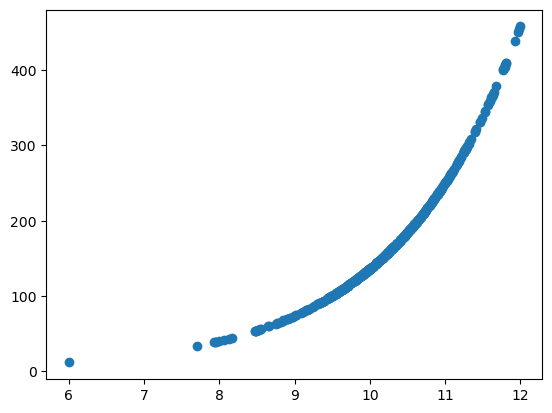

In [34]:
%matplotlib inline
plt.scatter(GDN_cat_v3["lgMs"], GDN_cat_v3["V22"])
plt.show()

In [28]:
test_hdul = fits.open(GDS_cutouts_fmt%199483)
test_hdul.info()

Filename: /xdisk/timeifler/jiachuanxu/jwst/fresco_gds/data_compile/data_compile_GDS_ID199483_substructdeproj.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      87   ()      
  1  PaA_AR        1 ImageHDU        35   (31, 31)   float32   
  2  PaA_ARN       1 ImageHDU        10   (31, 31)   float32   
  3  PaA_ARP       1 ImageHDU        26   (124, 124)   float32   
  4  PAA_ARM       1 ImageHDU        12   (31, 31)   float32   
  5  F444WIMG      1 ImageHDU        35   (62, 62)   float64   
  6  F444WERR      1 ImageHDU        11   (62, 62)   float32   
  7  F444WPSF      1 ImageHDU        23   (256, 256)   float64   
  8  F444WMSK      1 ImageHDU        12   (62, 62)   float64   


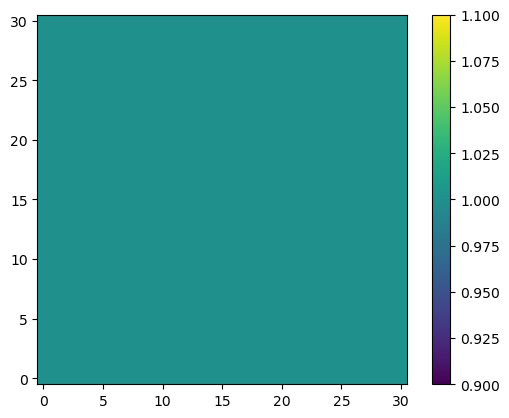

In [32]:
%matplotlib inline
plt.imshow(test_hdul["PaA_ARM"].data, origin="lower")
plt.colorbar()
plt.show()